# Attention After the Fact

### A causal-transformer post-mortem on retail demand

> **The scar:** an attention map can look like a causal diagram while quietly routing through a variable that happened *after* treatment.

This notebook builds a small, inspectable transformer to make that failure concrete. It uses the public **UCI Online Retail** transaction history to calibrate a realistic retail panel, then creates a transparent semi-synthetic treatment/outcome process with a known causal graph. The semi-synthetic step is intentional: the public retailer data do not contain randomized price interventions, so claiming a causal effect from raw attention would be dishonest.

We will train two otherwise identical one-layer transformers:

- **Standard attention:** the output token can attend to every feature, including a downstream promotion-reach mediator.
- **Causal feature mask:** the output token is forbidden from attending to that mediator, while still seeing treatment and pre-treatment context.

The notebook ends with attention maps, token-occlusion diagnostics, learned token geometry, and a counterfactual effect comparison. The goal is conceptual: watch the model learn the wrong shortcut, then make the forbidden path visible and remove it.

## 01 · The experiment contract

We define a known data-generating process:

\[
C \rightarrow T, \qquad C \rightarrow Y, \qquad T \rightarrow M \rightarrow Y, \qquad T \rightarrow Y
\]

where:

- \(C\) is pre-treatment context: product baseline and seasonality;
- \(T\) is a price-cut / promotion treatment;
- \(M\) is promotional reach, a **post-treatment mediator**;
- \(Y\) is demand.

The deliberately known structural coefficients are:

- direct treatment effect: `0.35`;
- treatment → mediator loading: `0.75`;
- mediator → demand loading: `0.55`;
- total effect: `0.35 + 0.75 × 0.55 = 0.7625`.

If a model controls for `M`, it is estimating the direct path, not the total treatment effect. If its attention simply *looks* at `M`, that does not make the path valid.

In [1]:
# Reproducible setup. The notebook is intentionally dependency-light.
import os
import sys
import math
import random
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The dark canvas is used only for the figures; the notebook text stays readable.
BG = "#0B1020"
PANEL = "#11182B"
INK = "#F4F7FB"
MUTED = "#9BA8C4"
CYAN = "#55D6BE"
MAGENTA = "#FF6B9A"
AMBER = "#F7C948"
BLUE = "#6EA8FE"
RED = "#FF7B72"
sns.set_theme(style="white", context="notebook")

print(f"device: {DEVICE} · seed: {SEED}")

device: cpu · seed: 7


## 02 · Public retail signal → a known causal stress test

The Kaggle candidates that best match the visual brief are [Favorita Store Sales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting) and [Walmart Recruiting Store Sales](https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting): both expose demand plus promotions/markdowns and calendar structure. Their competition downloads require accepting rules or using an API token, so this artifact uses the smaller [UCI Online Retail release](https://archive.ics.uci.edu/dataset/352/online+retail) directly.

The UCI history supplies real product-level demand scale and calendar coverage. We then generate treatment, mediator, and outcome variables with known coefficients. That preserves the public-data grounding while giving us a ground truth for the causal post-mortem.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
CACHE = Path("work") / "online_retail.xlsx"
CACHE.parent.mkdir(parents=True, exist_ok=True)

if not CACHE.exists():
    print("Downloading the public UCI workbook once …")
    urllib.request.urlretrieve(DATA_URL, CACHE)

raw = pd.read_excel(CACHE)
raw.columns = [c.strip() for c in raw.columns]
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])
raw["StockCode"] = raw["StockCode"].astype(str).str.strip()
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)

clean = raw[
    (raw["Quantity"] > 0)
    & (raw["UnitPrice"] > 0)
    & (~raw["InvoiceNo"].str.startswith("C"))
    & raw["StockCode"].notna()
].copy()
clean["date"] = clean["InvoiceDate"].dt.floor("D")

product_stats = (
    clean.groupby("StockCode")
    .agg(active_days=("date", "nunique"), volume=("Quantity", "sum"))
    .query("active_days >= 90")
    .sort_values("volume", ascending=False)
    .head(18)
)
keep_codes = product_stats.index.tolist()
dates = pd.date_range(clean["date"].min(), clean["date"].max(), freq="D")

daily = (
    clean[clean["StockCode"].isin(keep_codes)]
    .groupby(["StockCode", "date"])
    .agg(units=("Quantity", "sum"), transactions=("InvoiceNo", "nunique"), price=("UnitPrice", "median"))
    .reset_index()
)
dense = (
    pd.MultiIndex.from_product([keep_codes, dates], names=["StockCode", "date"])
    .to_frame(index=False)
    .merge(daily, on=["StockCode", "date"], how="left")
)
dense["units"] = dense["units"].fillna(0)
dense["transactions"] = dense["transactions"].fillna(0)
price_medians = dense.groupby("StockCode")["price"].transform("median")
dense["price"] = dense["price"].fillna(price_medians)
dense["log_units"] = np.log1p(dense["units"])

# Product baselines are the public-data anchor used by the semi-synthetic panel.
base = dense.groupby("StockCode")["log_units"].mean()
dense["product_base"] = dense["StockCode"].map(base)
dense["product_base"] = (dense["product_base"] - dense["product_base"].mean()) / dense["product_base"].std()
dense["dow"] = dense["date"].dt.dayofweek
dense["month"] = dense["date"].dt.month
dense["seasonality"] = (
    0.70 * np.sin(2 * np.pi * dense["dow"] / 7)
    + 0.35 * np.cos(2 * np.pi * dense["month"] / 12)
)

# This is the known stress-test DGP. `M` is intentionally downstream of `T`.
rng = np.random.default_rng(SEED)
n = min(6500, len(dense))
sample = dense.sample(n=n, random_state=SEED).reset_index(drop=True)
pre = 0.90 * sample["product_base"].to_numpy() + sample["seasonality"].to_numpy() + rng.normal(0, 0.18, n)
propensity = 1 / (1 + np.exp(-(-0.30 + 0.60 * pre + 0.25 * sample["seasonality"].to_numpy())))
treatment = rng.binomial(1, propensity)
mediator = 0.75 * treatment + 0.45 * sample["seasonality"].to_numpy() + 0.25 * pre + rng.normal(0, 0.18, n)
direct_effect = 0.35
mediator_effect = 0.55
demand = (
    0.65 * pre
    + direct_effect * treatment
    + mediator_effect * mediator
    + rng.normal(0, 0.22, n)
)

panel = pd.DataFrame({
    "product_base": sample["product_base"].to_numpy(),
    "seasonality": sample["seasonality"].to_numpy(),
    "treatment": treatment.astype(float),
    "mediator": mediator,
    "demand": demand,
    "public_log_units": sample["log_units"].to_numpy(),
    "date": sample["date"].to_numpy(),
})
true_total_effect = direct_effect + 0.75 * mediator_effect
print(f"public rows: {len(raw):,} → clean transactions: {len(clean):,}")
print(f"calibration panel: {len(dense):,} product-days → stress-test rows: {len(panel):,}")
print(f"treatment prevalence: {panel.treatment.mean():.1%} · known direct effect: {direct_effect:.2f} · known total effect: {true_total_effect:.4f}")
display(panel.head(5))

public rows: 541,909 → clean transactions: 530,104
calibration panel: 6,732 product-days → stress-test rows: 6,500
treatment prevalence: 43.1% · known direct effect: 0.35 · known total effect: 0.7625


,product_base,seasonality,treatment,mediator,demand,public_log_units,date
0,1.354517,0.857450,1.0,1.963425,2.523571,4.007333,2011-10-19
1,-1.639038,-0.175000,1.0,0.181056,-0.878705,0.000000,2011-04-18
2,1.109535,-0.722282,0.0,-0.214601,0.152266,0.000000,2011-08-07
3,-1.270668,0.128719,0.0,-0.057909,-0.836370,4.976734,2011-04-28
4,-0.496282,0.303719,0.0,0.037282,-0.045763,3.218876,2011-09-08


### The path we are trying to keep out of the output representation

`treatment → mediator → demand` is a real predictive route, but it is not a valid pre-treatment control path for a total-effect estimate. The model is allowed to *predict* demand from treatment; it is not allowed to claim that the mediator was an innocent confounder just because an attention head likes it.

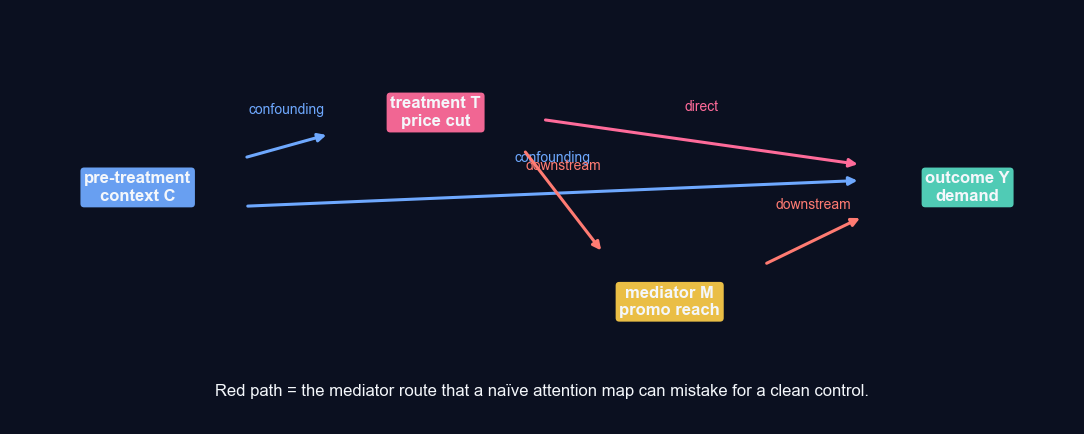

In [3]:
def node(ax, xy, label, color, width=0.22):
    ax.text(*xy, label, ha="center", va="center", color=INK, fontsize=12, weight="bold",
            bbox=dict(boxstyle=f"round,pad={width}", fc=color, ec="none", alpha=0.95))

def edge(ax, a, b, color, label=None, ls="-"):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="-|>", lw=2.2, color=color, linestyle=ls, shrinkA=18, shrinkB=18))
    if label:
        mid = ((a[0] + b[0]) / 2, (a[1] + b[1]) / 2)
        ax.text(mid[0], mid[1] + 0.08, label, color=color, fontsize=10, ha="center")

fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=BG)
ax.set_facecolor(BG)
node(ax, (0.12, 0.55), "pre-treatment\ncontext C", BLUE)
node(ax, (0.40, 0.74), "treatment T\nprice cut", MAGENTA)
node(ax, (0.62, 0.26), "mediator M\npromo reach", AMBER)
node(ax, (0.90, 0.55), "outcome Y\ndemand", CYAN)
edge(ax, (0.20, 0.61), (0.32, 0.70), BLUE, "confounding")
edge(ax, (0.20, 0.50), (0.82, 0.57), BLUE, "confounding")
edge(ax, (0.47, 0.69), (0.57, 0.34), RED, "downstream")
edge(ax, (0.69, 0.33), (0.82, 0.50), RED, "downstream")
edge(ax, (0.48, 0.73), (0.82, 0.60), MAGENTA, "direct")
ax.text(0.50, 0.02, "Red path = the mediator route that a naïve attention map can mistake for a clean control.", color=INK, ha="center", fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1); ax.axis("off")
plt.tight_layout()
plt.show()

## 03 · Turn the DAG into tokens

Every row becomes five scalar tokens:

`[CLS]  ·  product baseline  ·  seasonality  ·  treatment  ·  mediator`

The prediction is read only from `[CLS]`. The **standard** model lets `[CLS]` attend everywhere. The **causal feature mask** makes one surgical change: `[CLS] → mediator` is disallowed. This is a small architectural guardrail, not a substitute for identification assumptions.

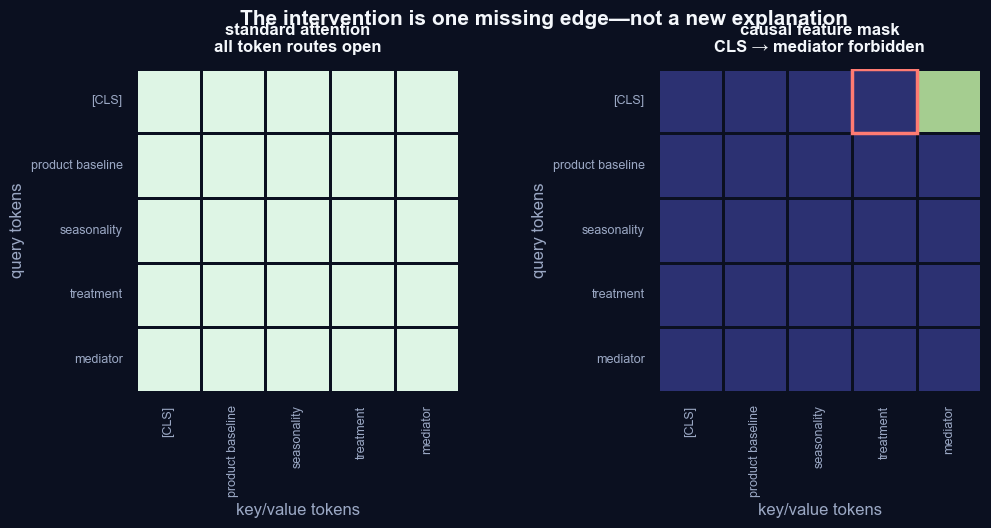

In [4]:
token_labels = ["[CLS]", "product baseline", "seasonality", "treatment", "mediator"]
allowed = np.ones((len(token_labels), len(token_labels)), dtype=bool)
allowed[0, 4] = False  # the output representation cannot read the post-treatment mediator

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), facecolor=BG, gridspec_kw={"wspace": 0.28})
for ax, matrix, title, cmap in [
    (axes[0], np.ones_like(allowed, dtype=float), "standard attention\nall token routes open", "mako"),
    (axes[1], allowed.astype(float), "causal feature mask\nCLS → mediator forbidden", "crest"),
]:
    ax.set_facecolor(BG)
    sns.heatmap(matrix, ax=ax, cmap=cmap, vmin=0, vmax=1, cbar=False,
                xticklabels=token_labels, yticklabels=token_labels,
                linewidths=1, linecolor=BG, square=True)
    ax.set_title(title, color=INK, fontsize=12, weight="bold", pad=12)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("key/value tokens", color=MUTED)
    ax.set_ylabel("query tokens", color=MUTED)
    for spine in ax.spines.values(): spine.set_visible(False)
axes[1].add_patch(plt.Rectangle((3, 0), 1, 1, fill=False, edgecolor=RED, lw=2.5))
fig.suptitle("The intervention is one missing edge—not a new explanation", color=INK, fontsize=15, weight="bold", y=1.02)
plt.show()

In [5]:
# Train/test split and scaling. Treatment stays binary; continuous tokens are z-scored.
feature_cols = ["product_base", "seasonality", "treatment", "mediator"]
raw_X = panel[feature_cols].to_numpy(dtype=np.float32)
raw_y = panel["demand"].to_numpy(dtype=np.float32)
idx = np.arange(len(panel))
rng_split = np.random.default_rng(SEED)
rng_split.shuffle(idx)
cut = int(0.78 * len(idx))
train_idx, test_idx = idx[:cut], idx[cut:]

cont_idx = np.array([0, 1, 3])
x_mean = raw_X[train_idx][:, cont_idx].mean(axis=0)
x_std = raw_X[train_idx][:, cont_idx].std(axis=0) + 1e-6
X = raw_X.copy()
X[:, cont_idx] = (X[:, cont_idx] - x_mean) / x_std
y_mean = raw_y[train_idx].mean()
y_std = raw_y[train_idx].std() + 1e-6
y = (raw_y - y_mean) / y_std

X_train = torch.tensor(X[train_idx], dtype=torch.float32, device=DEVICE)
y_train = torch.tensor(y[train_idx], dtype=torch.float32, device=DEVICE)
X_test = torch.tensor(X[test_idx], dtype=torch.float32, device=DEVICE)
y_test = torch.tensor(y[test_idx], dtype=torch.float32, device=DEVICE)
print(f"train: {len(train_idx):,} · test: {len(test_idx):,} · token width: {len(token_labels)}")

train: 5,070 · test: 1,430 · token width: 5


## 04 · A tiny transformer we can actually inspect

There is no hidden `TransformerEncoder` here. The attention scores are computed in a few lines so we can save the exact `query × key` tensor. One block is enough for this demonstration: the point is to see routing, not to win a leaderboard.

,RMSE (z),R²
standard,0.209,0.956
causal mask,0.262,0.932


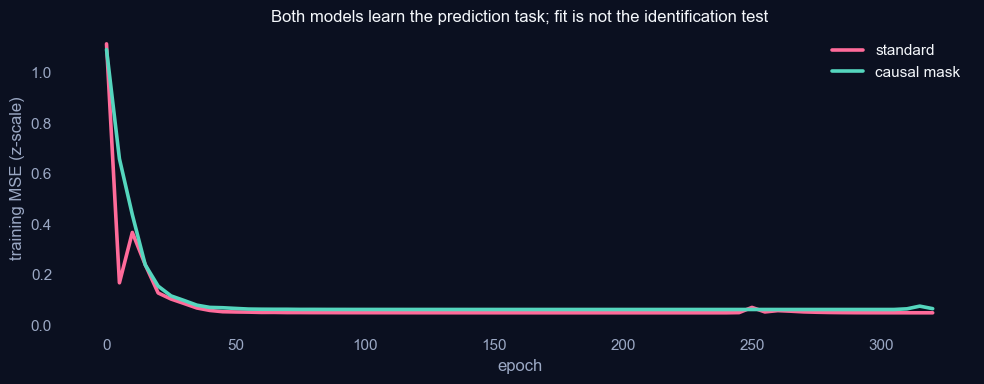

In [6]:
class InspectableBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 2 * d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d_model, d_model)
        )

    def forward(self, x, allowed_mask=None):
        batch, tokens, width = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(batch, tokens, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch, tokens, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch, tokens, self.n_heads, self.head_dim).transpose(1, 2)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if allowed_mask is not None:
            scores = scores.masked_fill(~allowed_mask[None, None, :, :], -1e9)
        attention = scores.softmax(dim=-1)
        mixed = attention @ v
        mixed = mixed.transpose(1, 2).contiguous().view(batch, tokens, width)
        x = self.norm1(x + self.out(mixed))
        x = self.norm2(x + self.ff(x))
        return x, attention


class AttentionTransformer(nn.Module):
    def __init__(self, masked=False, d_model=64, n_heads=4):
        super().__init__()
        self.masked = masked
        self.n_tokens = len(token_labels)
        self.value = nn.Linear(1, d_model)
        self.token_embedding = nn.Parameter(torch.randn(self.n_tokens, d_model) * 0.04)
        self.position_embedding = nn.Parameter(torch.randn(self.n_tokens, d_model) * 0.04)
        self.block = InspectableBlock(d_model=d_model, n_heads=n_heads)
        self.regressor = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Linear(d_model // 2, 1))
        if masked:
            mask = torch.ones(self.n_tokens, self.n_tokens, dtype=torch.bool)
            mask[0, 4] = False
            self.register_buffer("allowed_mask", mask)
        else:
            self.allowed_mask = None

    def forward(self, features):
        cls_value = torch.zeros((features.shape[0], 1), device=features.device, dtype=features.dtype)
        values = torch.cat([cls_value, features], dim=1).unsqueeze(-1)
        x = self.value(values) + self.token_embedding[None, :, :] + self.position_embedding[None, :, :]
        x, attention = self.block(x, self.allowed_mask)
        prediction = self.regressor(x[:, 0]).squeeze(-1)
        return prediction, attention


def fit(model, epochs=320, lr=0.008):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = []
    for epoch in range(epochs):
        model.train()
        pred, _ = model(X_train)
        loss = F.mse_loss(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 5 == 0 or epoch == epochs - 1:
            history.append(float(loss.detach().cpu()))
    return history


torch.manual_seed(SEED)
standard = AttentionTransformer(masked=False)
standard_history = fit(standard)
torch.manual_seed(SEED)
masked = AttentionTransformer(masked=True)
masked_history = fit(masked)

def score(model):
    model.eval()
    with torch.no_grad():
        pred, _ = model(X_test)
    return {
        "RMSE (z)": mean_squared_error(y_test.cpu(), pred.cpu(), squared=False),
        "R²": r2_score(y_test.cpu(), pred.cpu()),
    }

metrics = pd.DataFrame({"standard": score(standard), "causal mask": score(masked)}).T
display(metrics.round(3))

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.set_facecolor(BG)
xs = np.arange(len(standard_history)) * 5
ax.plot(xs, standard_history, color=MAGENTA, lw=2.6, label="standard")
ax.plot(xs, masked_history, color=CYAN, lw=2.6, label="causal mask")
ax.set(xlabel="epoch", ylabel="training MSE (z-scale)", title="Both models learn the prediction task; fit is not the identification test")
ax.tick_params(colors=MUTED); ax.xaxis.label.set_color(MUTED); ax.yaxis.label.set_color(MUTED)
ax.title.set_color(INK); ax.legend(frameon=False, labelcolor=INK)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout(); plt.show()

## 05 · What the heads learned to look at

We average the `[CLS]` row over the held-out set. This is not “the explanation”; it is the model’s routing pattern. The expected scar is simple: the standard model discovers that the mediator is highly predictive, while the masked model has no legal edge from `[CLS]` to the mediator.

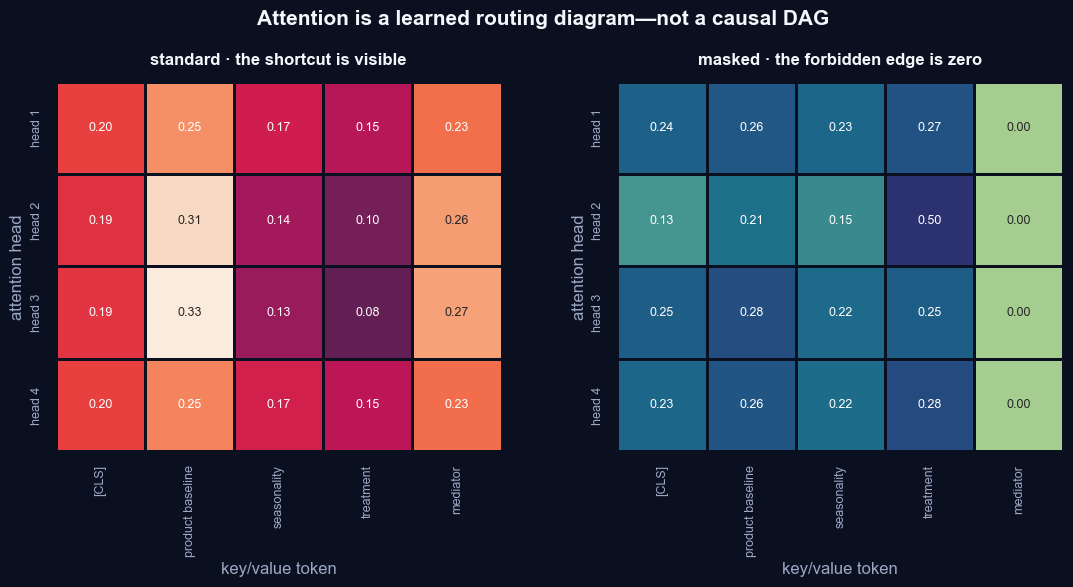

In [7]:
def cls_attention(model, X_batch):
    model.eval()
    with torch.no_grad():
        _, attn = model(X_batch)
    # [batch, heads, query, key] → mean over rows, keep each head's CLS query.
    return attn[:, :, 0, :].mean(dim=0).cpu().numpy()

attn_standard = cls_attention(standard, X_test)
attn_masked = cls_attention(masked, X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), facecolor=BG, gridspec_kw={"wspace": 0.26})
for ax, matrix, title, cmap in [
    (axes[0], attn_standard, "standard · the shortcut is visible", "rocket"),
    (axes[1], attn_masked, "masked · the forbidden edge is zero", "crest"),
]:
    ax.set_facecolor(BG)
    sns.heatmap(matrix, ax=ax, cmap=cmap, vmin=0, vmax=max(attn_standard.max(), 0.25),
                xticklabels=token_labels, yticklabels=[f"head {i+1}" for i in range(matrix.shape[0])],
                annot=True, fmt=".2f", annot_kws={"fontsize": 9}, linewidths=1, linecolor=BG, cbar=False)
    ax.set_title(title, color=INK, fontsize=12, weight="bold", pad=12)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("key/value token", color=MUTED); ax.set_ylabel("attention head", color=MUTED)
fig.suptitle("Attention is a learned routing diagram—not a causal DAG", color=INK, fontsize=15, weight="bold", y=1.03)
plt.show()

### Attention versus intervention

A second diagnostic removes one token at a time by replacing it with its training mean. This is not a perfect causal attribution either, but it is a useful sanity check: does the representation actually change when the model loses the token it was attending to?

,standard attention,standard occlusion,masked attention,masked occlusion
product_base,0.286,0.410,0.254,0.527
seasonality,0.151,0.230,0.207,0.450
treatment,0.121,0.094,0.326,0.278
mediator,0.248,0.357,0.000,0.000


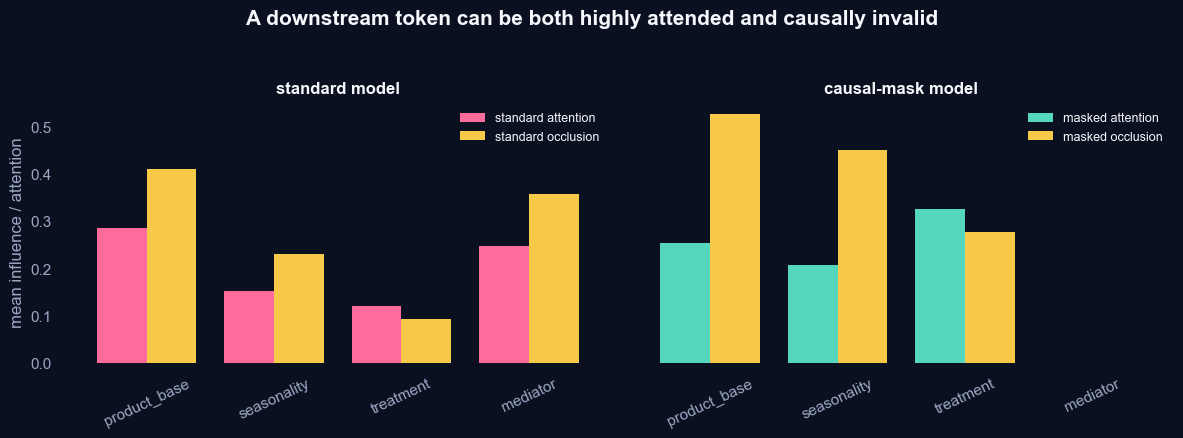

In [8]:
def occlusion_effect(model, X_batch):
    model.eval()
    with torch.no_grad():
        base, _ = model(X_batch)
    effects = []
    for j in range(X_batch.shape[1]):
        altered = X_batch.clone()
        altered[:, j] = 0.0
        with torch.no_grad():
            changed, _ = model(altered)
        effects.append(torch.mean(torch.abs(changed - base)).item())
    return np.array(effects)

occlusion = pd.DataFrame({
    "standard attention": attn_standard.mean(axis=0)[1:],
    "standard occlusion": occlusion_effect(standard, X_test),
    "masked attention": attn_masked.mean(axis=0)[1:],
    "masked occlusion": occlusion_effect(masked, X_test),
}, index=feature_cols)
display(occlusion.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), facecolor=BG, sharey=True)
for ax, prefix, title, color in [
    (axes[0], "standard", "standard model", MAGENTA),
    (axes[1], "masked", "causal-mask model", CYAN),
]:
    ax.set_facecolor(BG)
    vals = occlusion[[f"{prefix} attention", f"{prefix} occlusion"]]
    vals.plot.bar(ax=ax, color=[color, AMBER], width=0.78, edgecolor="none")
    ax.set_title(title, color=INK, weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("mean influence / attention", color=MUTED)
    ax.tick_params(axis="x", rotation=25, colors=MUTED); ax.tick_params(axis="y", colors=MUTED)
    ax.legend(frameon=False, labelcolor=INK, fontsize=9)
    for spine in ax.spines.values(): spine.set_visible(False)
fig.suptitle("A downstream token can be both highly attended and causally invalid", color=INK, fontsize=15, weight="bold", y=1.04)
plt.tight_layout(); plt.show()

## 06 · The counterfactual post-mortem

We now evaluate the models on the same contexts under two interventions. For each row, the expected mediator is generated as if `T=0` or `T=1`.

- **Direct / adjusted:** toggle treatment but hold the mediator at its untreated value. This is what a model that conditions on `M` is pushed toward.
- **Total / mediated:** toggle treatment and let the mediator move with treatment. This is the estimand encoded by the known data-generating process.

The mask should behave like a representation-level scrubber: it can use treatment and context, but cannot use the post-treatment mediator as an input to `[CLS]`.

estimand,direct / mediator held,total / mediator moves
model,,
causal mask,0.729,0.729
standard,0.247,0.768


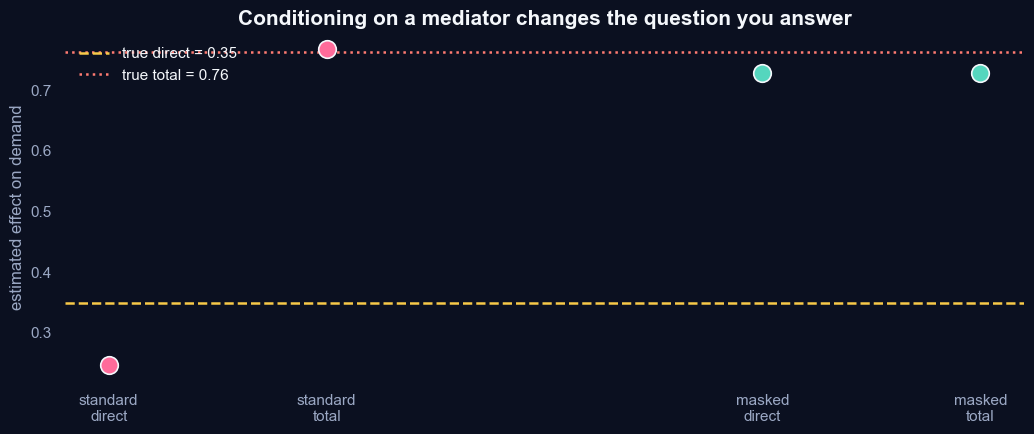

In [9]:
def scaled_from_raw(x_raw):
    x = x_raw.copy().astype(np.float32)
    x[:, cont_idx] = (x[:, cont_idx] - x_mean) / x_std
    return torch.tensor(x, dtype=torch.float32, device=DEVICE)

raw_test = raw_X[test_idx].copy()
pre_hat = 0.90 * raw_test[:, 0] + raw_test[:, 1]
mediator_untreated = 0.45 * raw_test[:, 1] + 0.25 * pre_hat
mediator_treated = mediator_untreated + 0.75

cf0 = raw_test.copy(); cf0[:, 2] = 0.0; cf0[:, 3] = mediator_untreated
cf1_direct = raw_test.copy(); cf1_direct[:, 2] = 1.0; cf1_direct[:, 3] = mediator_untreated
cf1_total = raw_test.copy(); cf1_total[:, 2] = 1.0; cf1_total[:, 3] = mediator_treated

def predict_original(model, x_tensor):
    model.eval()
    with torch.no_grad():
        pred, _ = model(x_tensor)
    return pred.cpu().numpy() * y_std + y_mean

effect_rows = []
for name, model in [("standard", standard), ("causal mask", masked)]:
    p0 = predict_original(model, scaled_from_raw(cf0))
    p1_direct = predict_original(model, scaled_from_raw(cf1_direct))
    p1_total = predict_original(model, scaled_from_raw(cf1_total))
    effect_rows.extend([
        {"model": name, "estimand": "direct / mediator held", "estimate": np.mean(p1_direct - p0)},
        {"model": name, "estimand": "total / mediator moves", "estimate": np.mean(p1_total - p0)},
    ])
effects = pd.DataFrame(effect_rows)
display(effects.pivot(index="model", columns="estimand", values="estimate").round(3))

fig, ax = plt.subplots(figsize=(10.5, 4.5), facecolor=BG)
ax.set_facecolor(BG)
positions = {("standard", "direct / mediator held"): 0, ("standard", "total / mediator moves"): 1,
             ("causal mask", "direct / mediator held"): 3, ("causal mask", "total / mediator moves"): 4}
colors = {"standard": MAGENTA, "causal mask": CYAN}
for row in effect_rows:
    x = positions[(row["model"], row["estimand"])]
    ax.scatter(x, row["estimate"], s=160, color=colors[row["model"]], edgecolor=INK, linewidth=1.2, zorder=3)
ax.axhline(direct_effect, color=AMBER, lw=1.8, ls="--", label=f"true direct = {direct_effect:.2f}")
ax.axhline(true_total_effect, color=RED, lw=1.8, ls=":", label=f"true total = {true_total_effect:.2f}")
ax.set_xticks([0, 1, 3, 4], ["standard\ndirect", "standard\ntotal", "masked\ndirect", "masked\ntotal"])
ax.set_ylabel("estimated effect on demand", color=MUTED)
ax.set_title("Conditioning on a mediator changes the question you answer", color=INK, fontsize=15, weight="bold")
ax.tick_params(colors=MUTED); ax.legend(frameon=False, labelcolor=INK, loc="upper left")
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout(); plt.show()

## 07 · Learned token geometry

The token embeddings are not causal objects either, but their geometry is a useful final “scar tissue” view: the model has learned separate roles for baseline context, seasonality, treatment, and the mediator. The masked model keeps the mediator token in the input sequence for diagnosis, while the output route is explicitly denied.

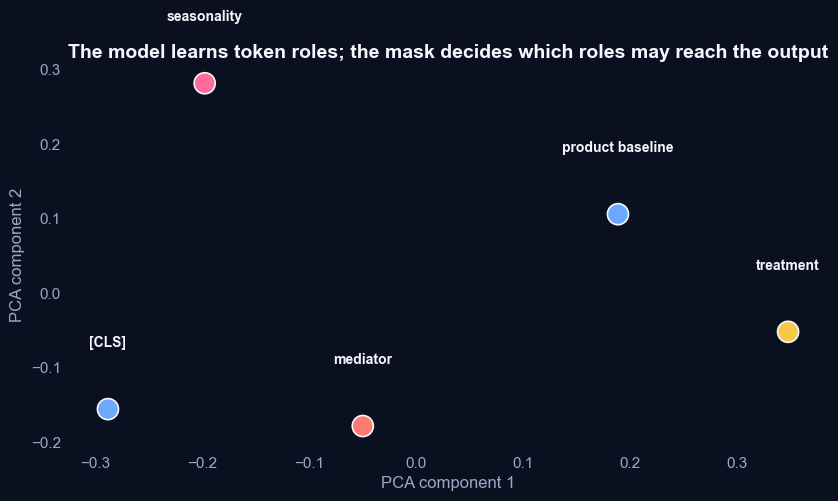

In [10]:
embedding = masked.token_embedding.detach().cpu().numpy()
projection = PCA(n_components=2, random_state=SEED).fit_transform(embedding)
fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor=BG)
ax.set_facecolor(BG)
ax.scatter(projection[:, 0], projection[:, 1], s=230, color=[BLUE, BLUE, MAGENTA, AMBER, RED], edgecolor=INK, linewidth=1.2)
for (x, y0), label in zip(projection, token_labels):
    ax.text(x, y0 + 0.08, label, color=INK, ha="center", va="bottom", fontsize=10, weight="bold")
ax.set_title("The model learns token roles; the mask decides which roles may reach the output", color=INK, fontsize=14, weight="bold")
ax.set_xlabel("PCA component 1", color=MUTED); ax.set_ylabel("PCA component 2", color=MUTED)
ax.tick_params(colors=MUTED)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout(); plt.show()

## Final post-mortem

1. **The standard model found a useful shortcut.** The mediator is genuinely predictive of demand, so an attention head has every incentive to route through it.
2. **Predictive usefulness did not make the mediator a valid control.** Holding it fixed while toggling treatment estimates the direct path and removes the mediated portion of the effect.
3. **The feature mask changed what the output representation was allowed to see.** In this controlled stress test, that keeps the total-effect question available without asking the model to “unlearn” a post-treatment shortcut after the fact.
4. **The mask is not magic.** A real causal claim still needs a defensible treatment assignment story, temporal ordering, overlap, measurement quality, and sensitivity analysis. Attention maps remain diagnostics, not identification proofs.

The conceptual takeaway is the same as the visual scar: **the model is not only learning what to look at; it is learning what it is allowed to see.**